In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### LOADING ORIGINAL IMAGE 

Image Shape: (1280, 1045)


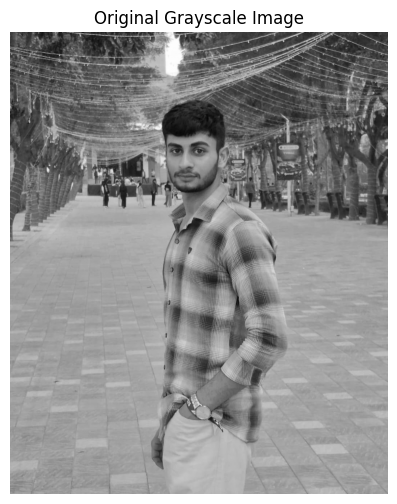

In [21]:

img = Image.open("yash.jpeg")

""" Convert image to grayscale """
gray_img = img.convert("L")

""" Convert to NumPy array """
img_matrix = np.array(gray_img)

"""  Display image  """
plt.figure(figsize=(6,6))
plt.imshow(img_matrix, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

print("Image Shape:", img_matrix.shape)

THE BELOW IMAGE  MATRIX IS PIXELS INTENSITY :
0 → pure black
255 → pure white
values in between → shades of gray

In [ ]:
print(img_matrix)

[[ 68  69  70 ...  66  64  61]
 [ 70  70  71 ...  62  62  62]
 [ 71  71  71 ...  62  64  66]
 ...
 [159 157 156 ... 149 147 147]
 [161 158 155 ... 152 148 144]
 [162 158 155 ... 158 152 147]]


 ### IMAGE AS MATRIX

In [22]:
print(img_matrix.shape)

(1280, 1045)


### APPLYING THE SVD ON IMAGE 

In [23]:
"""Apply Singular Value Decomposition"""
U, S, VT = np.linalg.svd(img_matrix, full_matrices=False)


print("U shape:", U.shape)
print("Singular Values shape:", S.shape)
print("VT shape:", VT.shape)

U shape: (1280, 1045)
Singular Values shape: (1045,)
VT shape: (1045, 1045)


SVD decomposes the image matrix into:

A=UΣV
T

Where:

U → important visual patterns
Σ → importance strength
Vᵀ → reconstruction direction

You should know this :

U
→ stores row patterns
S
→ stores importance scores
VT
→ stores column patterns

And:

large singular values = important information
small singular values = less important details

That’s the ENTIRE foundation of compression

####     RECONSTRUCT IMAGE USING TOP-k SINGULAR VALUES

In [24]:
""" Function to reconstruct image using top-k singular values"""
def reconstruct_image(U, S, VT, k):
    
    
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]
    
    
    compressed_img = U_k @ S_k @ VT_k
    
    return compressed_img

This is the ENTIRE compression idea:

Instead of keeping ALL information:

keep only most important singular values

That means:

less storage
less information
still recognizable image

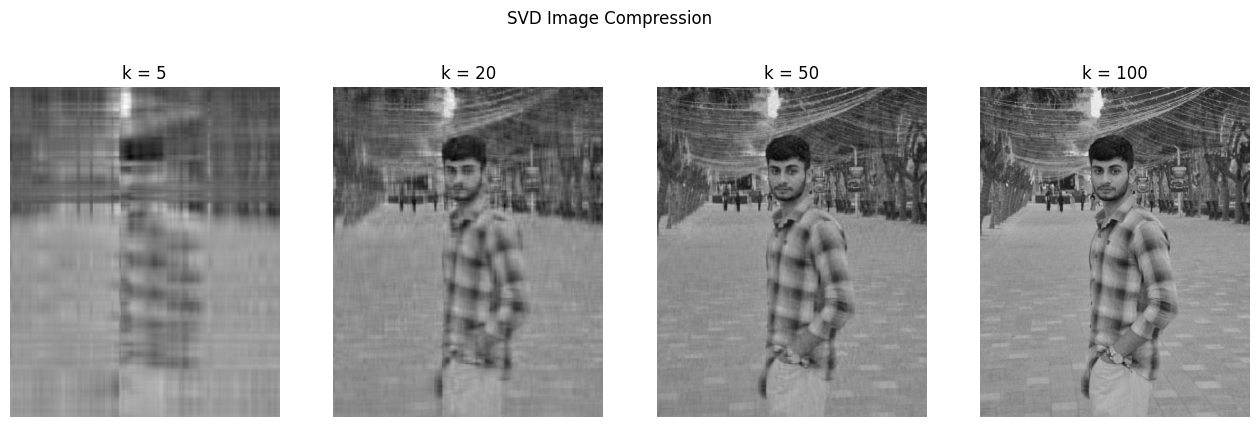

In [25]:

k_values = [5, 20, 50, 100]

""" Plot reconstructed images """
fig, axes = plt.subplots(1, len(k_values), figsize=(16,5))

for i, k in enumerate(k_values):
    
    compressed_img = reconstruct_image(U, S, VT, k)
    
    axes[i].imshow(compressed_img, cmap='gray')
    axes[i].set_title(f"k = {k}")
    axes[i].axis("off")

plt.suptitle("SVD Image Compression")
plt.show()



k=5 → blurry but recognizable
k=20 → much clearer
k=50 → surprisingly good
k=100 → almost original

“We reconstruct the image using only the most important patterns.”

### SINGULAR VALUE DECAY GRAPH (SINGULAR VALUES VS K VALUES )

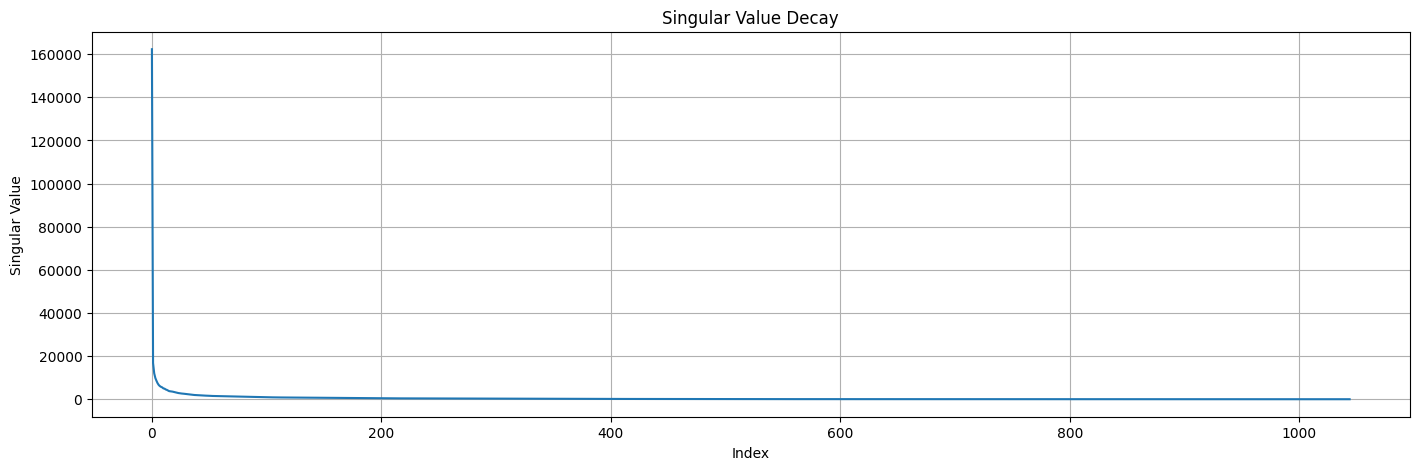

In [26]:


plt.figure(figsize=(17,5))

plt.plot(S)

plt.title("Singular Value Decay")
plt.xlabel("Index")
plt.ylabel("Singular Value")

plt.grid(True)

plt.show()

WHAT THIS SHOWS

This graph explains WHY compression works.

You’ll notice:

first few singular values are very large
later singular values become tiny

Meaning:

most visual information is concentrated in a few components

This is the REAL mathematical insight.

### STORAGE COMPARISON

In [27]:
"""Original storage"""
original_storage = img_matrix.shape[0] * img_matrix.shape[1]

"""Function to calculate compressed storage"""
def compressed_storage(k):
    return k * (1 + img_matrix.shape[0] + img_matrix.shape[1])


k_values = [5, 20, 50, 100]

print("Original Storage:", original_storage)

for k in k_values:
    
    compressed = compressed_storage(k)
    
    compression_ratio = original_storage / compressed
    
    print(f"\nk = {k}")
    print(f"Compressed Storage: {compressed}")
    print(f"Compression Ratio: {compression_ratio:.2f}x")

Original Storage: 1337600

k = 5
Compressed Storage: 11630
Compression Ratio: 115.01x

k = 20
Compressed Storage: 46520
Compression Ratio: 28.75x

k = 50
Compressed Storage: 116300
Compression Ratio: 11.50x

k = 100
Compressed Storage: 232600
Compression Ratio: 5.75x






 IMAGE STORAGE = rows × columns



### FINAL COPAARISON (ENDING )

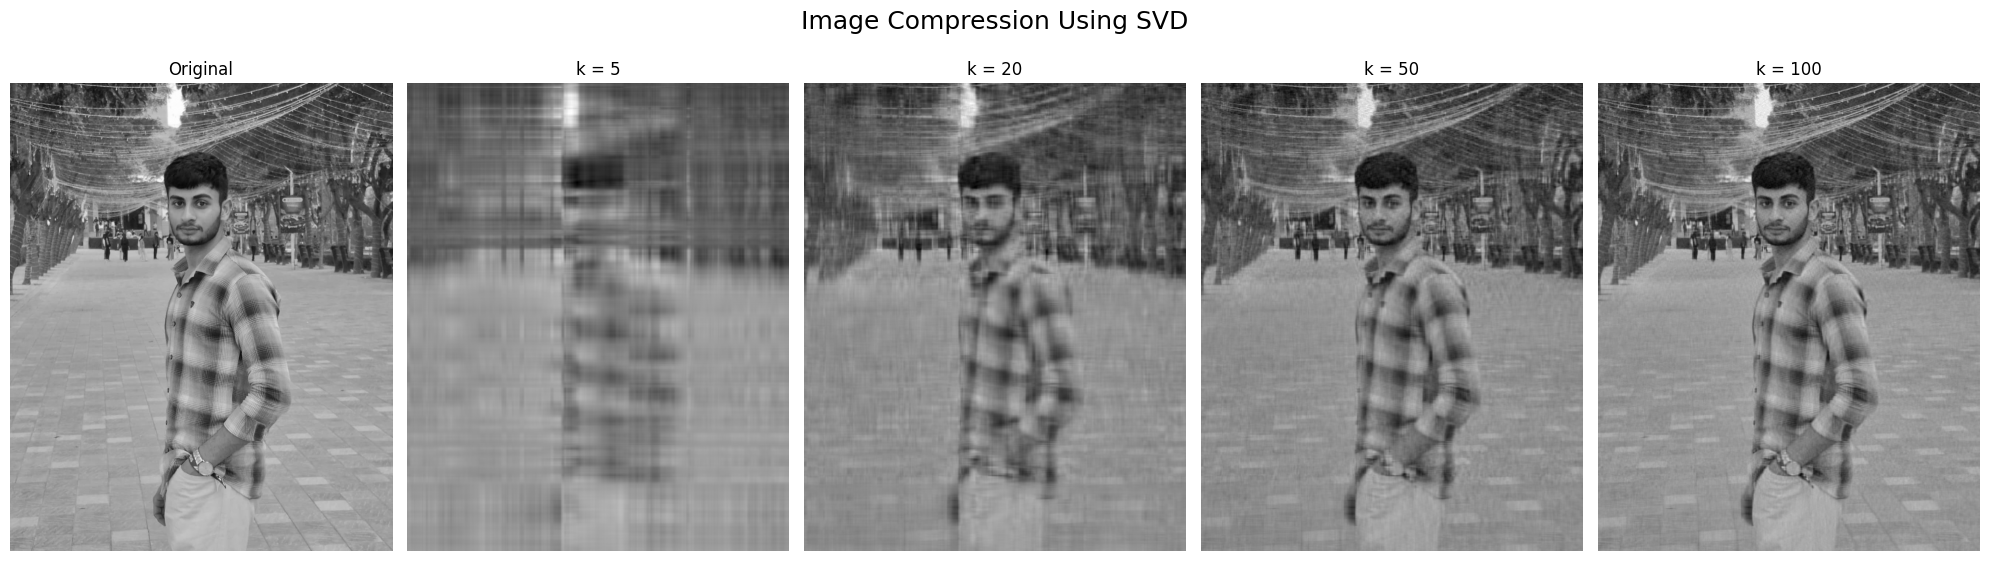

In [28]:


k_values = [5, 20, 50, 100]

fig, axes = plt.subplots(1, 5, figsize=(20,6))

""" Original image """
axes[0].imshow(img_matrix, cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

""" Compressed images """
for i, k in enumerate(k_values):
    
    compressed_img = reconstruct_image(U, S, VT, k)
    
    axes[i+1].imshow(compressed_img, cmap='gray')
    axes[i+1].set_title(f"k = {k}")
    axes[i+1].axis("off")

plt.suptitle("Image Compression Using SVD", fontsize=18)

plt.tight_layout()

plt.show()